# Processing Time Summary From Extracted CSV

This notebook reads the extracted summary table from `processing_time_summary_extracted.csv` and recreates the processing-time plot without re-running the log parsing workflow.

In [1]:
from pathlib import Path
import textwrap

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch

%matplotlib inline

sns.set_theme(style='whitegrid', font_scale=1.5)

BASE_DIR = Path.cwd()
CSV_PATH = BASE_DIR / 'processing_time_summary_extracted.csv'

if not CSV_PATH.exists():
    raise FileNotFoundError(f'CSV not found: {CSV_PATH}')

print(f'Using CSV: {CSV_PATH}')

Using CSV: /home/gustavo/orion-near-rt/analysis/times/processing_time_summary_extracted.csv


In [2]:
df = pd.read_csv(CSV_PATH)

numeric_columns = [
    'count',
    'mean_ms',
    'std_dev_ms',
    'min_ms',
    'max_ms',
    'corr_rate_pct',
    'cv_pct',
]

df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric)
df

,layer,component,label,count,mean_ms,std_dev_ms,min_ms,max_ms,corr_rate_pct,cv_pct
0,E2 Node,e2sim,E2 Node Control Processing,4,0.66,0.06,0.62,0.75,0.0,9.1
1,E2 Node,e2sim,E2 Node Slice Registration,4,0.62,0.07,0.57,0.72,0.0,11.3
2,Frontend,frontend,Frontend Connection,4,2.30,0.23,2.00,2.48,0.0,10.0
3,Frontend,frontend,Frontend E2E Response,5,8431.38,2010.83,5643.96,10633.23,0.0,23.8
4,Near-RT RIC,a1mediator,A1 Mediator Processing,24,2.38,1.48,0.66,5.25,0.0,62.2
5,Near-RT RIC,orion-xapp,xApp Full Policy Processing,82,6.36,0.85,5.32,8.87,0.0,13.4
6,Near-RT RIC,orion-xapp,xApp Policy→Control,59,169.65,105.42,12.66,356.23,0.0,62.1
7,Near-RT RIC,orion-xapp,xApp Wait for E2 ACK,5,2.51,2.03,1.52,6.14,0.0,80.9
8,SMO,mcp-client,SMO Intent→Policy,4,9025.39,1413.60,7661.47,10485.20,0.0,15.7
9,SMO,mcp-client,SMO LLM→Tool Start,4,3434.98,416.41,3008.25,3982.62,0.0,12.1


In [3]:
flow_order = [
    'E2 Node Slice Registration',
    'E2 Node Control Processing',
    'xApp Wait for E2 ACK',
    'xApp Policy→Control',
    'xApp Full Policy Processing',
    'A1 Mediator Processing',
    'rApp PUT to Non-RT RIC',
    'rApp Policy Translation',
    'MCP Server Session→Request',
    'SMO Policy Creation',
    'SMO MCP Tool Execution',
    'SMO LLM→Tool Start',
    'SMO Intent→Policy',
    'Frontend Connection',
    'Frontend E2E Response',
]

layer_colors = {
    'Frontend': '#CE93D8',
    'SMO': '#B39DDB',
    'rApp': '#81C784',
    'Non-RT RIC': '#81C784',
    'Near-RT RIC': '#64B5F6',
    'E2 Node': '#FFCC80',
}

plot_df = df.copy()
plot_df['flow_order'] = plot_df['label'].apply(lambda value: flow_order.index(value) if value in flow_order else 999)
plot_df = plot_df.sort_values('flow_order', ascending=False).reset_index(drop=True)
plot_df[['layer', 'component', 'label', 'count', 'mean_ms', 'std_dev_ms', 'cv_pct']]

,layer,component,label,count,mean_ms,std_dev_ms,cv_pct
0,Frontend,frontend,Frontend E2E Response,5,8431.38,2010.83,23.8
1,Frontend,frontend,Frontend Connection,4,2.30,0.23,10.0
2,SMO,mcp-client,SMO Intent→Policy,4,9025.39,1413.60,15.7
3,SMO,mcp-client,SMO LLM→Tool Start,4,3434.98,416.41,12.1
4,SMO,mcp-client,SMO MCP Tool Execution,4,47.30,9.62,20.3
5,SMO,mcp-client,SMO Policy Creation,4,5508.44,1438.16,26.1
6,SMO,mcp-server,MCP Server Session→Request,2,15070.26,2323.66,15.4
7,rApp,rapp,rApp Policy Translation,8,112.37,34.52,30.7
8,rApp,rapp,rApp PUT to Non-RT RIC,4,111.91,37.15,33.2
9,Near-RT RIC,a1mediator,A1 Mediator Processing,24,2.38,1.48,62.2


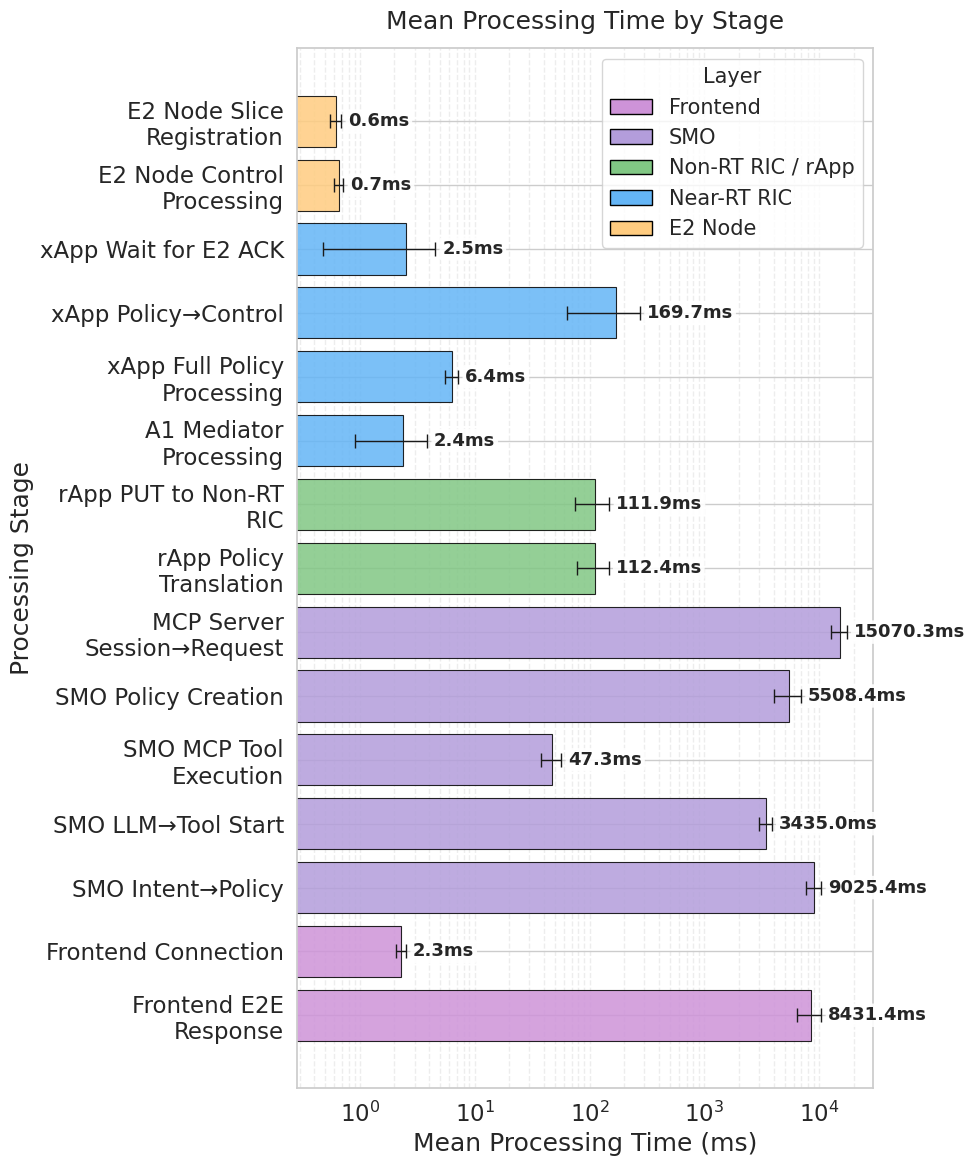

Saved plot to: processing_time_by_stage_from_csv.png
Saved plot to: processing_time_by_stage_from_csv.pdf


In [7]:
labels = [textwrap.fill(label, 20) for label in plot_df['label']]
means = plot_df['mean_ms'].to_numpy()
stds = plot_df['std_dev_ms'].to_numpy()
colors = [layer_colors.get(layer, '#888888') for layer in plot_df['layer']]

fig, ax = plt.subplots(figsize=(10, max(6, len(labels) * 0.8)))
bars = ax.barh(
    labels,
    means,
    xerr=stds,
    capsize=5,
    color=colors,
    edgecolor='black',
    linewidth=0.8,
    alpha=0.85,
    error_kw=dict(lw=1, capsize=5, capthick=1),
)

for bar, mean, std in zip(bars, means, stds):
    if mean <= 0:
        continue

    width_right = mean + std if std > 0 else mean
    ax.annotate(
        f'{mean:.1f}ms',
        xy=(width_right, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),
        textcoords='offset points',
        ha='left',
        va='center',
        fontsize=13,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.9),
    )

ax.set_title('Mean Processing Time by Stage', pad=14)
ax.set_xlabel('Mean Processing Time (ms)')
ax.set_ylabel('Processing Stage')
ax.set_xscale('log')
ax.grid(axis='x', linestyle='--', alpha=0.35, which='both')

legend_elements = [
    Patch(facecolor='#CE93D8', edgecolor='black', label='Frontend'),
    Patch(facecolor='#B39DDB', edgecolor='black', label='SMO'),
    Patch(facecolor='#81C784', edgecolor='black', label='Non-RT RIC / rApp'),
    Patch(facecolor='#64B5F6', edgecolor='black', label='Near-RT RIC'),
    Patch(facecolor='#FFCC80', edgecolor='black', label='E2 Node'),
]
ax.legend(handles=legend_elements, loc='upper right', title='Layer', fontsize='small', title_fontsize='small')

png_path = BASE_DIR / 'processing_time_by_stage_from_csv.png'
pdf_path = BASE_DIR / 'processing_time_by_stage_from_csv.pdf'

plt.tight_layout()
plt.savefig(png_path, dpi=300, bbox_inches='tight')
plt.savefig(pdf_path, bbox_inches='tight')
plt.show()

print(f'Saved plot to: {png_path.name}')
print(f'Saved plot to: {pdf_path.name}')